In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import datetime
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import MSTL, DecomposeResult
import re
import ESP_funcs as esp

from importlib import reload

# Load data and remove downtime

#### Load data

The provided data includes timestamps where 'Well_down' == True ('VSD power frequency' < 7). We remove these rows from the data to reduce memory usage, as their values are not passed to the pipeline.

In [ ]:
# Reading hourly data removing when well is down

data_hour = pd.read_csv('dados equinor - teams/full_sensor_1h [old].csv')
data_hour.index = pd.to_datetime(data_hour.index)

data_hour = data_hour[data_hour['Well_down']==0]
data_hour.drop(['Well_down'],axis=1,inplace=True)

data_hour.to_csv("hour_data_run.csv",index=False)


In [ ]:
# Reading features from minute data removing when well is down

data_min = pd.read_csv('dados equinor - teams/full_sensor_1min_resampled_V2 [old].csv')
data_min.index = pd.to_datetime(data_min.index)

data_min = data_min[data_min['Well_down']==0]
data_min.drop(['Well_down'],axis=1,inplace=True)

data_min.to_csv("min_data_run.csv",index=False)


In [ ]:
# Merging data to one DataFrame

data_full = pd.merge(data_hour,data_min,on=['time','Well Run'],how='outer')

# Removing data when frequency < 7 Hz
data_full = data_full[~pd.isna(data_full['VSD power frequency'])]
data_full = data_full[data_full['VSD power frequency'] > 7]

data_full.set_index('time',inplace=True)
data_full.index = pd.to_datetime(data_full.index)
data_full.index = data_full.index.tz_localize(None)

del(data_min)
del(data_hour)

In [43]:
# Reading failure table

data_failure = pd.read_excel("Peregrino ESP Run Life 240410 [SMALL].xlsx",skiprows=2)

# Função de substituição
def substituir(match):
    return f" {match.group(1)}"

# Substituição usando expressão regular
for dat in data_failure.index:
    data_failure.loc[dat,'Well Name'] = re.sub(r'\(#(\d+)\)', substituir, data_failure.loc[dat,'Well Name'])
    if len(data_failure.loc[dat,'Well Name']) in [4,5]:
        data_failure.loc[dat,'Well Name'] = f"{data_failure.loc[dat,'Well Name']} 1"

data_failure.set_index('Well Name',inplace=True)

name = data_failure.index

wells = data_full['Well Run'].unique()

#a = [i in wells for i in name]

#data_failure = data_failure.loc[fail_wells]


c:\Users\Heitor\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\Heitor\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


#### Removing repeated data

Some wells have repeated data.

Well A-09 1 has a failure date of 4 of December 2013, and there is indeed a data gap on that date. However, it resumes after a while. Further inspection shows that this portion of data is equal to the data from A-09 2.

In [ ]:
data_A = data_full[data_full['Well Run']== 'A-09 1']
data_B = data_full[data_full['Well Run']== 'A-09 2']

a = data_A['VSD power frequency']
b = data_B['VSD power frequency']

data_A['VSD power frequency'].iloc[8815:8850].plot(style='o')

plt.figure()
(a-b).plot()

plt.figure()
a.iloc[8816::].plot()
b.plot()

plt.figure()
a.plot(style='.')

Using the data as is, some measurements get repeated. Thus, all data at least 24 hours after the failure date is discarded (as failure date does not specify hour)

In [42]:
fail_wells = []
for well in data_full['Well Run'].unique():

    # Getting failure date for a specific well
    ind = data_failure.index==well
    fail_date = data_failure[ind]['Failure Date'].values

    # Testing if failure date is before the end date
    ind_well = data_full['Well Run'] == well
    dates_well = ind_well[ind_well].index
    end_date = dates_well.max()
    if bool(data_failure[ind]['ESP Health'].values) is False:
        a = fail_date[0] - dates_well

        if a.min().days==0:
            a = a - datetime.timedelta(seconds=a.min().seconds)
        elif a.min().days == -1:
            a = a - datetime.timedelta(seconds=a.min().seconds, days=-1)

        data_full.loc[ind_well, 'Failure distance'] = a

        fail_wells.append(well)
    else:
        data_full.loc[ind_well, 'Failure distance'] = pd.NA
        print(well)
        
data_full = data_full[~(data_full['Failure distance'].dt.components.days < 0)]

B-18 3
A-24 2
0 0


#### Saving the data

After this pre-processing, the data is saved again, under one file

In [ ]:
data_full.to_csv("merged_data1.csv",index=True)
data_full.to_csv("merged_data2.csv",index=False)

# Plot data before failure

In [3]:
# Load data if reopen
data_full = pd.read_csv("merged_data.csv",index_col='time')
data_full.index = pd.to_datetime(data_full.index)
data_full.index = data_full.index.tz_localize(None)
data_full['Failure distance'] = pd.to_timedelta(data_full['Failure distance'])


To visualize some data, we can plot them 

['B-22 1' 'A-08 1' 'B-14 1' 'B-18 1' 'A-03 1' 'B-08 3' 'B-23 2' 'A-18 1'
 'B-09 1' 'B-18 2' 'B-19 1' 'B-13 1' 'A-09 1' 'B-03 1' 'A-23 1' 'A-24 1'
 'A-22 1' 'B-17 1' 'B-18 3' 'B-05 1' 'A-12 1' 'A-22 2' 'A-03 2' 'A-12 2'
 'A-08 2' 'B-07 2' 'A-09 2' 'B-22 2' 'A-18 2' 'B-04 1' 'B-02 1' 'B-27 1'
 'A-10 1' 'B-01 1' 'B-04 2' 'A-17 1' 'B-16 1' 'A-29 1' 'B-04 3' 'B-21 1'
 'A-04 1' 'A-24 2' 'B-10 1' 'A-22 3' 'A-29 2' 'A-28 1' 'A-15 1' 'B-22 3'
 'B-16 2' 'A-27 1' 'B-26 1' 'A-21 1' 'A-06 1' 'A-06 2' 'B-30A 1' 'A-21 2']


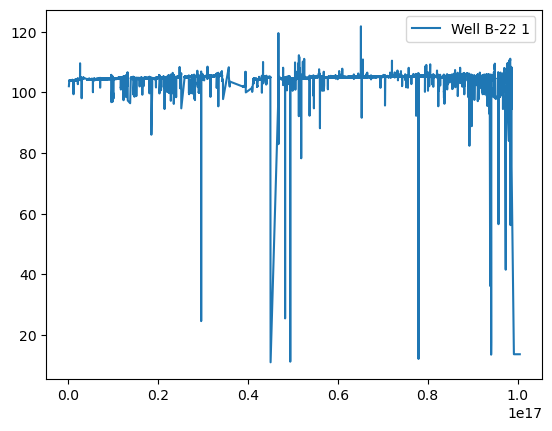

In [8]:
data_name = 'ESP motor temperature'

fig = plt.figure()
ax = fig.add_subplot(111)

for well in data_full['Well Run'].unique()[:1]:
    
    data_well = data_full[data_full['Well Run']==well]
    x = data_well['Failure distance']
    y = data_well[data_name]

    plt.plot(x,y,label=f'Well {well}');


plt.legend()

print(data_full['Well Run'].unique())

# Dividing data into blocks

Some of the data is divided in operational blocks. That is, sometimes there is a sudden change in the mean of the data, as the operation condition changes. Furthermore, sometimes, there is a large gap in the date.

In [1]:
vsd_name = 'VSD power frequency'

well = 'B-23 2'

data_well = data_full[data_full['Well Run'] ==well]

vsd = data_well['VSD power frequency']
fail = data_well['Failure distance'] < datetime.timedelta(days=100)

# Getting first and last days
year1 = np.min(vsd.index.year)
month1 = np.min(vsd.index[vsd.index.year==year1].month)

year2 = np.max(vsd.index.year)
month2 = np.max(vsd.index[vsd.index.year==year2].month)+1
if month2 == 13:
    month2 = 1
    year2 += 1

#vsd.index = vsd.index.tz_localize(None)

# Creating date range
first = datetime.datetime(year1, month1, 1, 0, 0, 0)
last = datetime.datetime(year2, month2, 1, 0, 0, 0)
dates = pd.date_range(start=first, end=last, freq='H')

days = pd.DataFrame(index = dates,
                   data = np.zeros(dates.size))


days.loc[vsd.index,0] = 1

# Dividing by groups
block_space = 7
division_dates = vsd.index[vsd.index.to_series().diff().dt.days>block_space]
blcks = [None]*(division_dates.size+1)
nblcs = 0

if division_dates.size == 0:
    blcks[nblcs] = vsd
    nblcs = 1

else:
    for i in range(division_dates.size):
        
        if i>0:
            vsd_loc =  vsd.loc[np.logical_and(vsd.index<division_dates[i],vsd.index>=division_dates[i-1])]
        else:
            vsd_loc = vsd.loc[vsd.index<division_dates[i]]
    
        if vsd_loc.size > 0: 
            if (vsd_loc.index[-1]-vsd_loc.index[0]).days > block_space:
                blcks[nblcs] = vsd_loc
                nblcs += 1

    vsd_loc =  vsd.loc[vsd.index>=division_dates[i]]
    if vsd_loc.size > 0:
        if (vsd_loc.index[-1]-vsd_loc.index[0]).days > block_space:
            blcks[nblcs] = vsd_loc
            nblcs += 1


plt.figure()
print(nblcs)

for i in range(nblcs):
    vsd_loc = blcks[i]

    # Detecting outliers
    Q1 = vsd_loc.abs().quantile(q=0.25)
    Q3 = vsd_loc.abs().quantile(q=0.75)
    IQR = Q3 - Q1

    no_outliers = (Q1 - 1.5*IQR < vsd_loc) &  (vsd_loc < Q3 + 1.5*IQR)
    outliers= no_outliers == False
    vsd_loc = vsd_loc[no_outliers]


    mn = vsd_loc.rolling('24h').mean()
    st = vsd_loc.rolling('24h').std()

    md = vsd_loc.median()
    
    

    #print(st)

    #c = b.drop(b[np.abs(b-mn)>1*st].index,inplace=False)
    #c = b.drop(b[np.abs(b-md)>qt].index,inplace=False)
    
    plt.figure(1)
    #plt.plot(outliers.rolling(24).sum())
    vsd_loc.plot(style='.')

    plt.figure(2)
    #vsd_loc.plot(style='k-')
    mn.plot(style='b.')
   # (2*st+mn).plot(style='r--')
    #(-2*st+mn).plot(style='r--')
    #plt.ylim([-1,1])

for i in [1,2]:
    plt.figure(i)
    plt.grid(True)
    plt.gcf().set_size_inches(12,5)



NameError: name 'data_full' is not defined

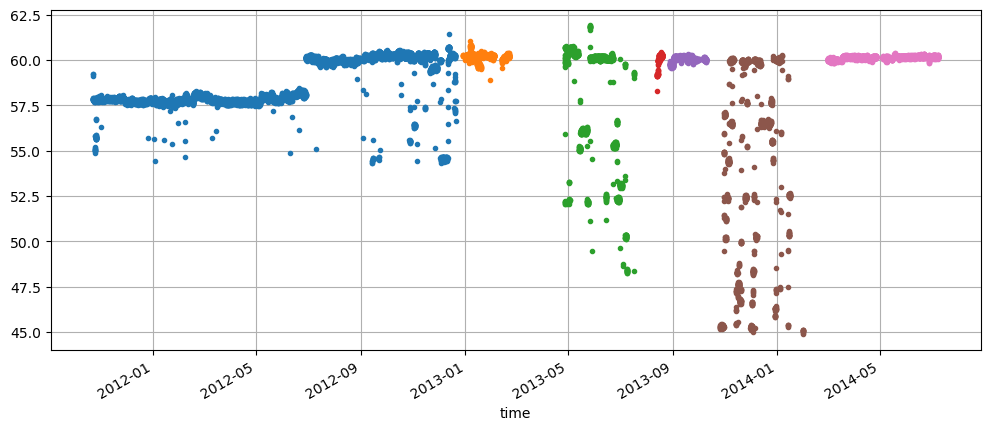

In [ ]:
reload(esp)
blcks = esp.get_blocks(data_full, well,max_na=7,min_size=7)

well_data = data_full[data_full['Well Run'] ==well]
nblcs = len(blcks)
for i in range(nblcs):
    ind = blcks[i]
    vsd_loc = well_data.loc[ind,'VSD power frequency']

    vsd_loc = esp.remove_outliers(vsd_loc)[0]
    
    plt.figure(1)
    vsd_loc.plot(style='.')
    
    plt.grid(True)
    plt.gcf().set_size_inches(12,5)




In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Autocorrelation of block
for i in range(len(blcks)):
#for i in [0]:
    vsd_loc = blcks[i]

    # Detecting outliers
    Q1 = vsd_loc.abs().quantile(q=0.25)
    Q3 = vsd_loc.abs().quantile(q=0.75)
    IQR = Q3 - Q1

    no_outliers = (Q1 - 1.5*IQR < vsd_loc) &  (vsd_loc < Q3 + 1.5*IQR)
    outliers= no_outliers == False
    vsd_loc = vsd_loc[no_outliers]


    mstl = MSTL(vsd_loc,periods=[24,7*24])

    res = mstl.fit()

    res.plot()


    T = res.trend
    S = res.seasonal
    R = res.resid

    vR = R.var()
    FT = max(0,1-vR/(T+R).var())

    if isinstance(S,pd.DataFrame):
        FS = [None]*S.columns.size
        for i in range(S.columns.size):
            FS[i] = max(0,1-vR/(S[S.columns[i]]+R).var())
    else:
        FS = max(0,1-vR/(S+R).var())

    print(FT,FS)

In [ ]:
S

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Autocorrelation of block
#for i in range(nblcs):
for i in [0]:
    vsd_loc = blcks[i]

    # Detecting outliers
    Q1 = vsd_loc.abs().quantile(q=0.25)
    Q3 = vsd_loc.abs().quantile(q=0.75)
    IQR = Q3 - Q1

    no_outliers = (Q1 - 1.5*IQR < vsd_loc) &  (vsd_loc < Q3 + 1.5*IQR)
    outliers= no_outliers == False
    vsd_loc = vsd_loc[no_outliers]

    print(vsd_loc.size//2)
    plot_acf(vsd_loc,lags=range(0,vsd_loc.size//3));

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf


full_data = pd.Series()
# Autocorrelation of block
#for i in range(len(blcks)):
for i in [0]:
    vsd_loc = blcks[i]

    # Detecting outliers
    Q1 = vsd_loc.abs().quantile(q=0.25)
    Q3 = vsd_loc.abs().quantile(q=0.75)
    IQR = Q3 - Q1

    no_outliers = (Q1 - 1.5*IQR < vsd_loc) &  (vsd_loc < Q3 + 1.5*IQR)
    outliers= no_outliers == False
    vsd_loc = vsd_loc[no_outliers]


    avg = vsd_loc.rolling(24).mean()
    de_avg = vsd_loc-avg

    plt.figure(1)
    vsd_loc.plot();
    plt.figure(2)
    de_avg.plot();
    plt.figure(3);
    de_avg.dropna(inplace=True)
    #a = acf(de_avg.values,nlags=24*7);

    ind = vsd_loc.index
    data = data_well.loc[ind,'Well head pressure']
    
    full_data = pd.concat((full_data,data))

    #ind = np.abs(a)>0.1
    #plt.plot(np.where(ind)[0],a[ind],'b.')

## Motif and Stumpy

In [ ]:
import stumpy
from matplotlib.patches import Rectangle

m = 24*30

mp = stumpy.stump(avg,m)

In [ ]:
motif_idx = np.argsort(mp[:, 0])[0]

print(f"The motif is located at index {motif_idx}")

In [ ]:
nearest_neighbor_idx = mp[motif_idx, 1]

print(f"The nearest neighbor is located at index {nearest_neighbor_idx}")

In [ ]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Motif (Pattern) Discovery', fontsize='30')

axs[0].plot(avg.values)
axs[0].set_ylabel('Steam Flow', fontsize='20')
rect = Rectangle((motif_idx, 56), m, 3, facecolor='lightgrey')
axs[0].add_patch(rect)
rect = Rectangle((nearest_neighbor_idx, 57), m, 4, facecolor='lightgrey')
axs[0].add_patch(rect)
axs[1].set_xlabel('Time', fontsize ='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=motif_idx, linestyle="dashed")
axs[1].axvline(x=nearest_neighbor_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])
plt.show()

## A

In [ ]:
m = 24*30
n = 24*7

a = full_data.rolling(n).mean().dropna()

mp = stumpy.stump(a,m)

discord_idx = np.argsort(mp[:, 0])[-1]

print(f"The discord is located at index {discord_idx}")

In [ ]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Discord (Anomaly/Novelty) Discovery', fontsize='30')

axs[0].plot(a.values)
axs[0].set_ylabel('Steam Flow', fontsize='20')
#rect = Rectangle((discord_idx, -0.1), m, 0.4, facecolor='lightgrey')
rect = Rectangle((discord_idx, 19), m, 0.4, facecolor='lightgrey')
axs[0].add_patch(rect)
axs[0].set_ylim([10,30])
axs[1].set_xlabel('Time', fontsize ='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=discord_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])
plt.show()

In [ ]:
variance = avg.rolling(m).var().dropna().values

plt.plot(variance)

In [ ]:
annotation_vector = (variance < 0.02).astype(np.float64)
plt.plot(annotation_vector)

In [ ]:
mp.shape, variance.shape
#corrected_mp = mp[:, 0] + ((1 - annotation_vector) * np.max(mp[:, 0]))

## B

In [ ]:
from scipy.signal import butter, lfilter, freqz
# Create filter

fs = 30
cutoff = 0.5
order = 6

b,a = butter(order,cutoff,fs=fs,btype='low',analog=False)

w, h = freqz(b, a, fs=fs, worN=8000)

plt.subplot(2, 1, 1)
plt.plot(w, np.abs(h), 'b')
plt.plot(cutoff, 0.5*np.sqrt(2), 'ko')
plt.axvline(cutoff, color='k')
plt.xlim(0, 0.5*fs)
plt.title("Lowpass Filter Frequency Response")
plt.xlabel('Frequency [Hz]')
plt.grid()


In [ ]:
d = lfilter(b,a,data)

plt.plot(d,'b-')
plt.ylim([10,24])

plt.figure()
plt.plot(data,'r:')
plt.ylim([10,24])